# Model Training

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import IsolationForest 
from sklearn.neighbors import LocalOutlierFactor 
from sklearn.covariance import EllipticEnvelope  
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed

In [5]:
# Load data - using relative path for portability
data_path = pd.read_csv(r"C:\Users\Akshay\Desktop\building-energy-anomaly-detection\data\meters\whole\eda.csv")
df = data_path

# Convert timestamp to datetime if not already done
if df['timestamp'].dtype == 'object':
    df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by timestamp if not already sorted
if not df['timestamp'].is_monotonic_increasing:
    df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (140352, 1637)
Columns: ['timestamp', 'Panther_office_Clementine', 'Panther_lodging_Cora', 'Panther_education_Teofila', 'Panther_education_Jerome', 'Panther_retail_Kristina', 'Panther_education_Neal', 'Panther_lodging_Kara', 'Panther_office_Garth', 'Panther_office_Lavinia', 'Panther_education_Enriqueta', 'Panther_lodging_Marisol', 'Panther_education_Aurora', 'Panther_lodging_Kirk', 'Panther_education_Vincent', 'Panther_office_Brent', 'Panther_office_Karla', 'Panther_education_Quintin', 'Panther_other_Bettie', 'Panther_education_Annetta', 'Panther_education_Ivan', 'Panther_office_Graham', 'Panther_education_Emily', 'Panther_education_Cleopatra', 'Panther_office_Christian', 'Panther_education_Zelda', 'Fox_lodging_Stephen', 'Fox_lodging_Stephan', 'Fox_office_Israel', 'Fox_education_Lilly', 'Fox_education_Gayla', 'Fox_lodging_Warren', 'Fox_education_Andre', 'Fox_retail_Manie', 'Fox_assembly_Emma', 'Fox_office_Margarita', 'Fox_lodging_Frances', 'Fox_office_Demetrius', 'Fox_of

### Feature Preparation

In [6]:
# Select numeric columns for modeling (exclude timestamp)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove timestamp from numeric_cols if present
if 'timestamp' in numeric_cols:
    numeric_cols.remove('timestamp')

print(f"Number of numeric features: {len(numeric_cols)}")

# Check if we have any numeric columns
if len(numeric_cols) == 0:
    raise ValueError("No numeric columns found in the dataset!")

# Prepare feature matrix with NaN handling
X = df[numeric_cols].fillna(0).values

# Handle any remaining NaN values
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Feature matrix shape: {X.shape}")

Number of numeric features: 1636
Feature matrix shape: (140352, 1636)


### Model Training

In [7]:
# Define training functions for parallel execution
def train_isolation_forest(X):
    """Train Isolation Forest model"""
    iso_forest = IsolationForest(
        n_estimators=100,
        contamination=0.05,
        random_state=42,
        n_jobs=-1
    )
    return iso_forest.fit_predict(X), iso_forest

def train_local_outlier_factor(X):
    """Train Local Outlier Factor model"""
    lof = LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.05,
        n_jobs=-1
    )
    return lof.fit_predict(X)

def train_elliptic_envelope(X):
    """
    Train Elliptic Envelope with adaptive parameters based on data dimensions.
    Includes error handling for edge cases.
    """
    n_samples = len(X)
    n_features = X.shape[1]
    
    # Check if we have enough samples for the model
    if n_samples < 10:
        print("Warning: Not enough samples for EllipticEnvelope. Skipping...")
        return np.ones(n_samples, dtype=int), None
    
    # Determine support_fraction based on data dimensions
    if n_samples < 100 or n_features > 500:
        support_fraction = 0.5
    elif n_samples < 500 or n_features > 1000:
        support_fraction = 0.6
    else:
        support_fraction = 0.7
    
    # Standardize features for better performance
    try:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        robust_cov = EllipticEnvelope(
            contamination=0.05,
            random_state=42,
            support_fraction=support_fraction
        )
        anomaly_pred = robust_cov.fit_predict(X_scaled)
        return anomaly_pred, robust_cov
    except Exception as e:
        print(f"Warning: EllipticEnvelope failed with error: {e}")
        return None, None

# Train models in parallel using joblib for faster execution
print("Training models in parallel...")

results = Parallel(n_jobs=-1, verbose=1)(
    delayed(train_isolation_forest)(X) for _ in [1]
)
anomaly_iso, iso_forest = results[0]

# Train LOF
anomaly_lof = train_local_outlier_factor(X)

# Train Elliptic Envelope
anomaly_maha, robust_cov = train_elliptic_envelope(X)

# Fallback if EllipticEnvelope failed
if anomaly_maha is None:
    anomaly_maha = anomaly_iso
    print("Using Isolation Forest results for Elliptic Envelope slot.")

print("3 models built successfully")
print("Anomaly detection complete!")

Training models in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
c:\Users\Akshay\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
c:\Users\Akshay\anaconda3\Lib\site-packages\sklearn\covariance\_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


Using Isolation Forest results for Elliptic Envelope slot.
3 models built successfully
Anomaly detection complete!


### Model Evaluation

In [8]:
# Each model votes: 1 if anomaly (-1), 0 if normal (1)
df['anomaly_votes'] = ((anomaly_iso == -1).astype(int) + 
                        (anomaly_lof == -1).astype(int) + 
                        (anomaly_maha == -1).astype(int))
df['is_anomaly'] = (df['anomaly_votes'] >= 2).astype(int)

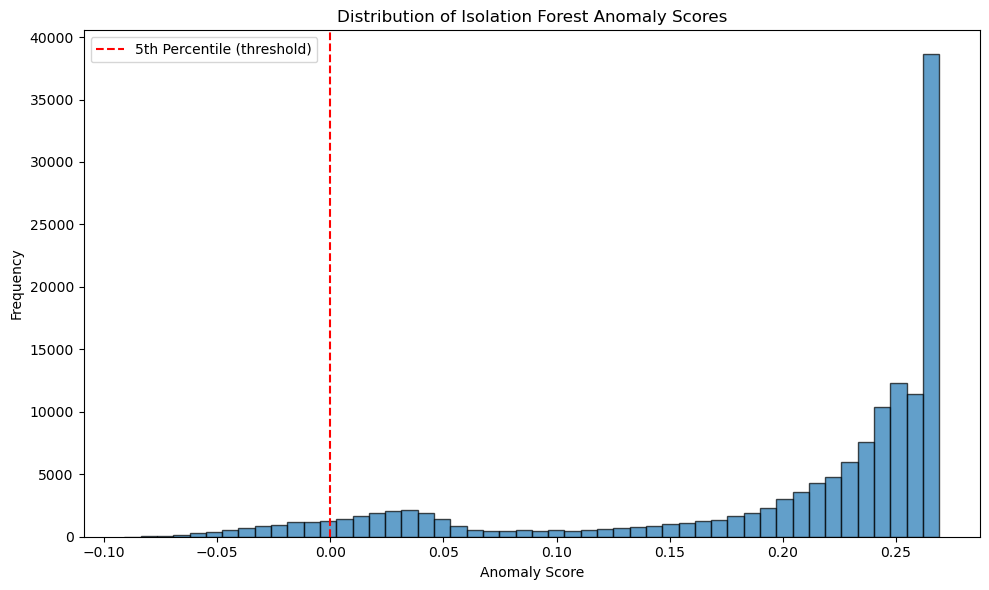

In [9]:
# Using decision_function scores to understand anomaly severity
anomaly_scores = iso_forest.decision_function(X)

# Create a dataframe with scores
scores_df = pd.DataFrame({
    'score': anomaly_scores,
    'is_anomaly': df['is_anomaly']
})

# Plot anomaly score distribution
plt.figure(figsize=(10, 6))
plt.hist(anomaly_scores, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.axvline(x=np.percentile(anomaly_scores, 5), color="red", linestyle="--", 
            label="5th Percentile (threshold)")
plt.legend()
plt.tight_layout()
plt.savefig("anomaly_scores_distribution.png", dpi=300)
plt.show()

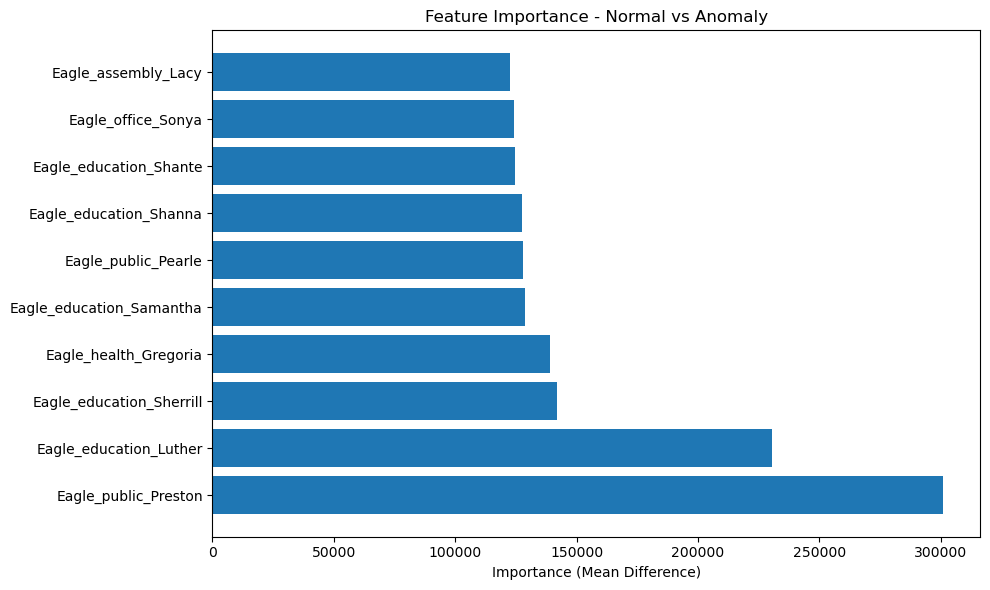

In [10]:
# Using feature means for normal vs anomalous data
feature_importance = {}

for col in numeric_cols:
    try:
        normal_mean = df[df["is_anomaly"] == 0][col].mean()
        anomaly_mean = df[df["is_anomaly"] == 1][col].mean()
        # Higher difference indicates more important feature
        feature_importance[col] = abs(anomaly_mean - normal_mean)
    except:
        feature_importance[col] = 0

# Sort by importance
feature_importance = dict(sorted(feature_importance.items(), 
                                  key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 6))
plt.barh(list(feature_importance.keys())[:10], 
         list(feature_importance.values())[:10])
plt.xlabel("Importance (Mean Difference)")  
plt.title("Feature Importance - Normal vs Anomaly")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

Detected 7018 anomalies (5.0%)


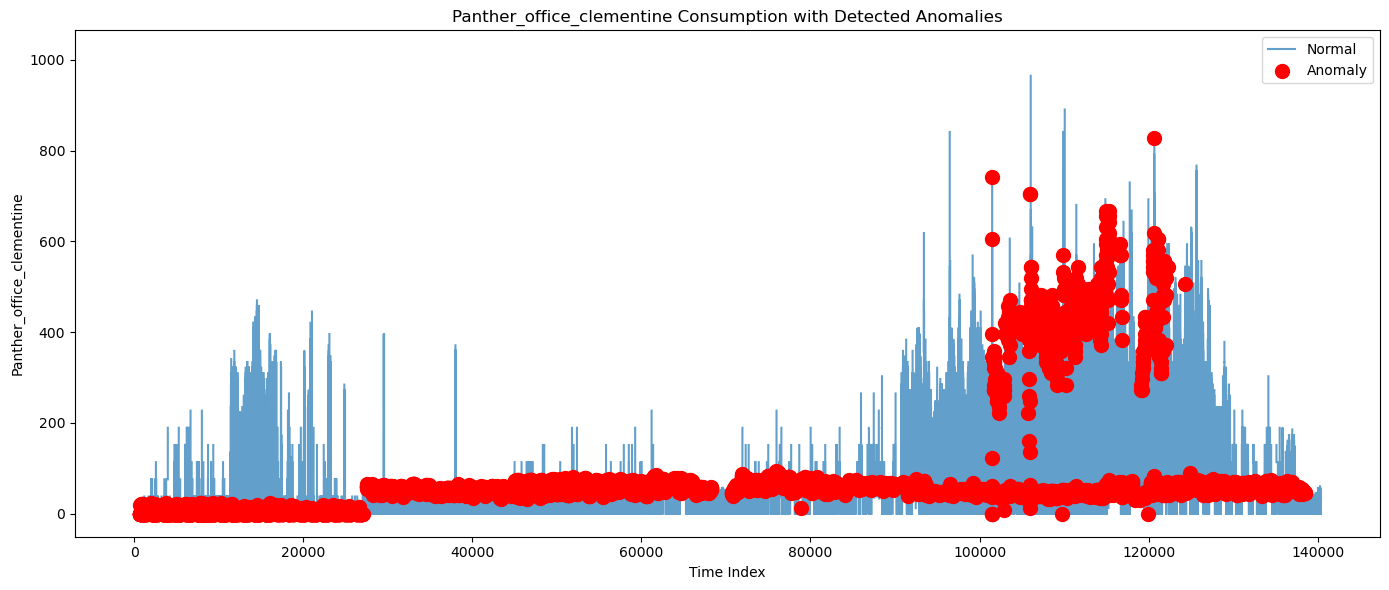

In [11]:
# Anomaly detection results
anomaly_df = df[df["is_anomaly"] == 1] 

total_points = len(df)
anomaly_count = len(anomaly_df)
percentage = (anomaly_count / total_points * 100) if total_points > 0 else 0

print(f"Detected {anomaly_count} anomalies ({percentage:.1f}%)") 

# Time series visualization of anomalies
plt.figure(figsize=(14, 6)) 

# Check if 'electricity' column exists
if 'electricity' not in df.columns:
    print("Warning: 'electricity' column not found. Using first numeric column instead.")
    plot_col = numeric_cols[0] if len(numeric_cols) > 0 else None
else:
    plot_col = 'electricity'

if plot_col is not None:
    # Plot normal data
    plt.plot(range(len(df)), df[plot_col][:len(df)], 
             label="Normal", alpha=0.7)

    # Plot anomalies
    anomaly_df_plot = df[df["is_anomaly"] == 1]
    if len(anomaly_df_plot) > 0:
        plt.scatter(anomaly_df_plot.index, anomaly_df_plot[plot_col], 
                    color="red", label="Anomaly", s=100, zorder=5)

    plt.xlabel("Time Index")
    plt.ylabel(plot_col.capitalize())
    plt.legend()
    plt.title(f"{plot_col.capitalize()} Consumption with Detected Anomalies")
    plt.tight_layout()
    plt.savefig("anomaly_detection_plot.png", dpi=300)
    plt.show()
else:
    print("No numeric column available for plotting.")

In [14]:
# Summary statistics
print("\n=== Anomaly Detection Summary ===")
print(f"Total data points: {total_points}")
print(f"Normal points: {total_points - anomaly_count}")
print(f"Anomalous points: {anomaly_count}")
print(f"\nAnomaly votes distribution:")
print(df["anomaly_votes"].value_counts().sort_index())

# Save results
output_path = r"C:\Users\Akshay\Desktop\building-energy-anomaly-detection\results\anomaly_detection_results.csv"
df.to_csv(output_path, index=False)

print(f"\nResults saved to {output_path}")


=== Anomaly Detection Summary ===
Total data points: 140352
Normal points: 133334
Anomalous points: 7018

Anomaly votes distribution:
anomaly_votes
0    126378
1      6956
2      6956
3        62
Name: count, dtype: int64

Results saved to C:\Users\Akshay\Desktop\building-energy-anomaly-detection\results\anomaly_detection_results.csv


In [15]:
## Laoding the Anomaly Dataset

df_anomaly = pd.read_csv(r"C:\Users\Akshay\Desktop\building-energy-anomaly-detection\results\anomaly_detection_results.csv")    
df.head(10)

,timestamp,Panther_office_Clementine,Panther_lodging_Cora,Panther_education_Teofila,Panther_education_Jerome,Panther_retail_Kristina,Panther_education_Neal,Panther_lodging_Kara,Panther_office_Garth,Panther_office_Lavinia,...,Panther_other_Ismael,Panther_education_Jarrett,Panther_education_Guillermina,Panther_lodging_Alyssa,Panther_retail_Jeanette,Panther_office_Bryce,Panther_lodging_Carroll,Panther_office_Gino,anomaly_votes,is_anomaly
0,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
2,2016-01-01 00:00:00,NaN,0.000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
3,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,2016-01-01 00:00:00,0.000,378.541,0.3785,75.7082,NaN,0.0,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0,0
5,2016-01-01 00:00:00,NaN,NaN,NaN,7486.8429,17.8688,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
6,2016-01-01 00:00:00,15.363,0.000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
7,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
8,2016-01-01 01:00:00,0.000,378.541,0.3785,75.7082,NaN,0.0,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0,0
9,2016-01-01 01:00:00,0.000,0.000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
